# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [19]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
from torch.utils.data import DataLoader, random_split
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

## Parte 0 - Teste Unitário

In [20]:
# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
# synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
# synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(synthetic_model, synthetic_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")


Treinando no dispositivo: cpu


KeyboardInterrupt: 

Média global mAP: 0.1076
Média global Erro Absoluto de Contagem: 8.9701


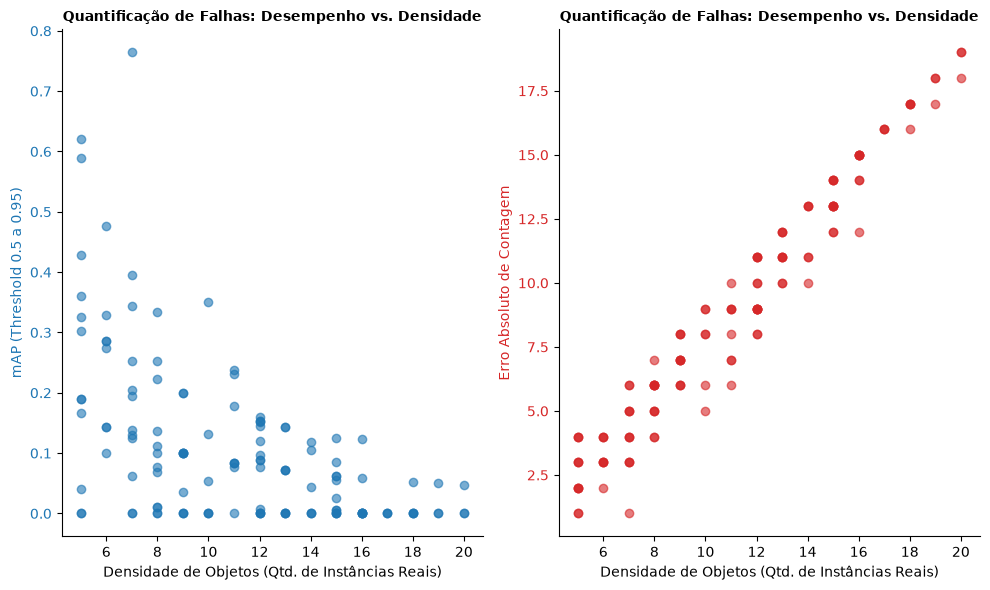

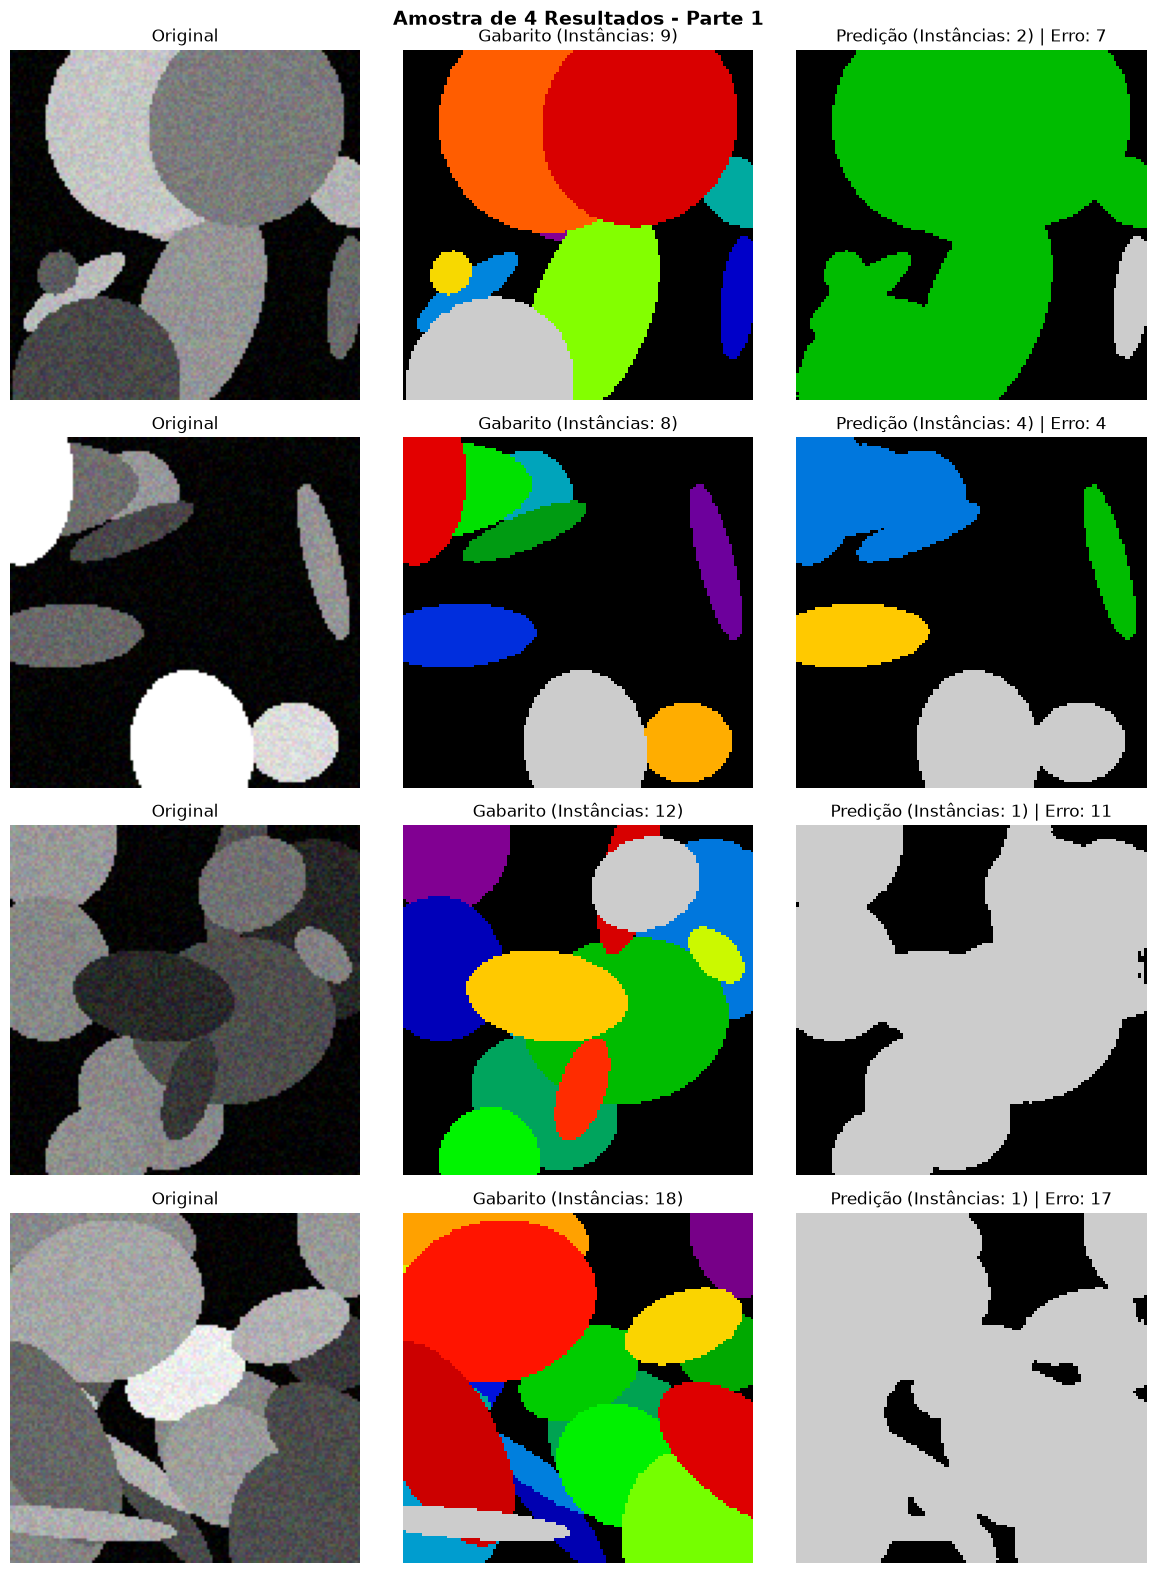

In [ ]:
synthetic_mAP, synthetic_count_errors, synthetic_densities, synthetic_samples = evaluate(synthetic_model, synthetic_val_loader, device, part =1)
plot_metrics(synthetic_mAP, synthetic_count_errors, synthetic_densities)
plot_samples(synthetic_samples, part=1)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

## Parte 1

In [21]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=1, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Treinando no dispositivo: cpu
Epoch 1/10 | Loss: 0.2940 | IoU: 0.0002 | Dice: 0.0004
Epoch 2/10 | Loss: 0.1605 | IoU: 0.4980 | Dice: 0.6649
Epoch 3/10 | Loss: 0.1133 | IoU: 0.7062 | Dice: 0.8278
Epoch 4/10 | Loss: 0.1046 | IoU: 0.7271 | Dice: 0.8420
Epoch 5/10 | Loss: 0.0994 | IoU: 0.7412 | Dice: 0.8514
Epoch 6/10 | Loss: 0.0969 | IoU: 0.7496 | Dice: 0.8569
Epoch 7/10 | Loss: 0.0905 | IoU: 0.7694 | Dice: 0.8697
Epoch 8/10 | Loss: 0.0836 | IoU: 0.7833 | Dice: 0.8785
Epoch 9/10 | Loss: 0.0811 | IoU: 0.7884 | Dice: 0.8817
Epoch 10/10 | Loss: 0.0791 | IoU: 0.7943 | Dice: 0.8854


Média global mAP: 0.3934
Média global Erro Absoluto de Contagem: 13.8060


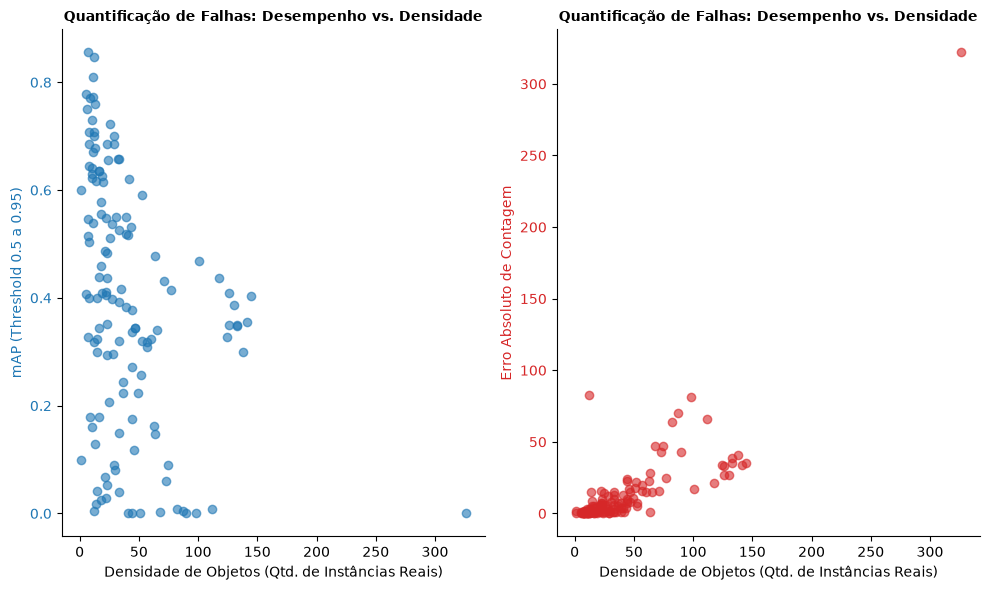

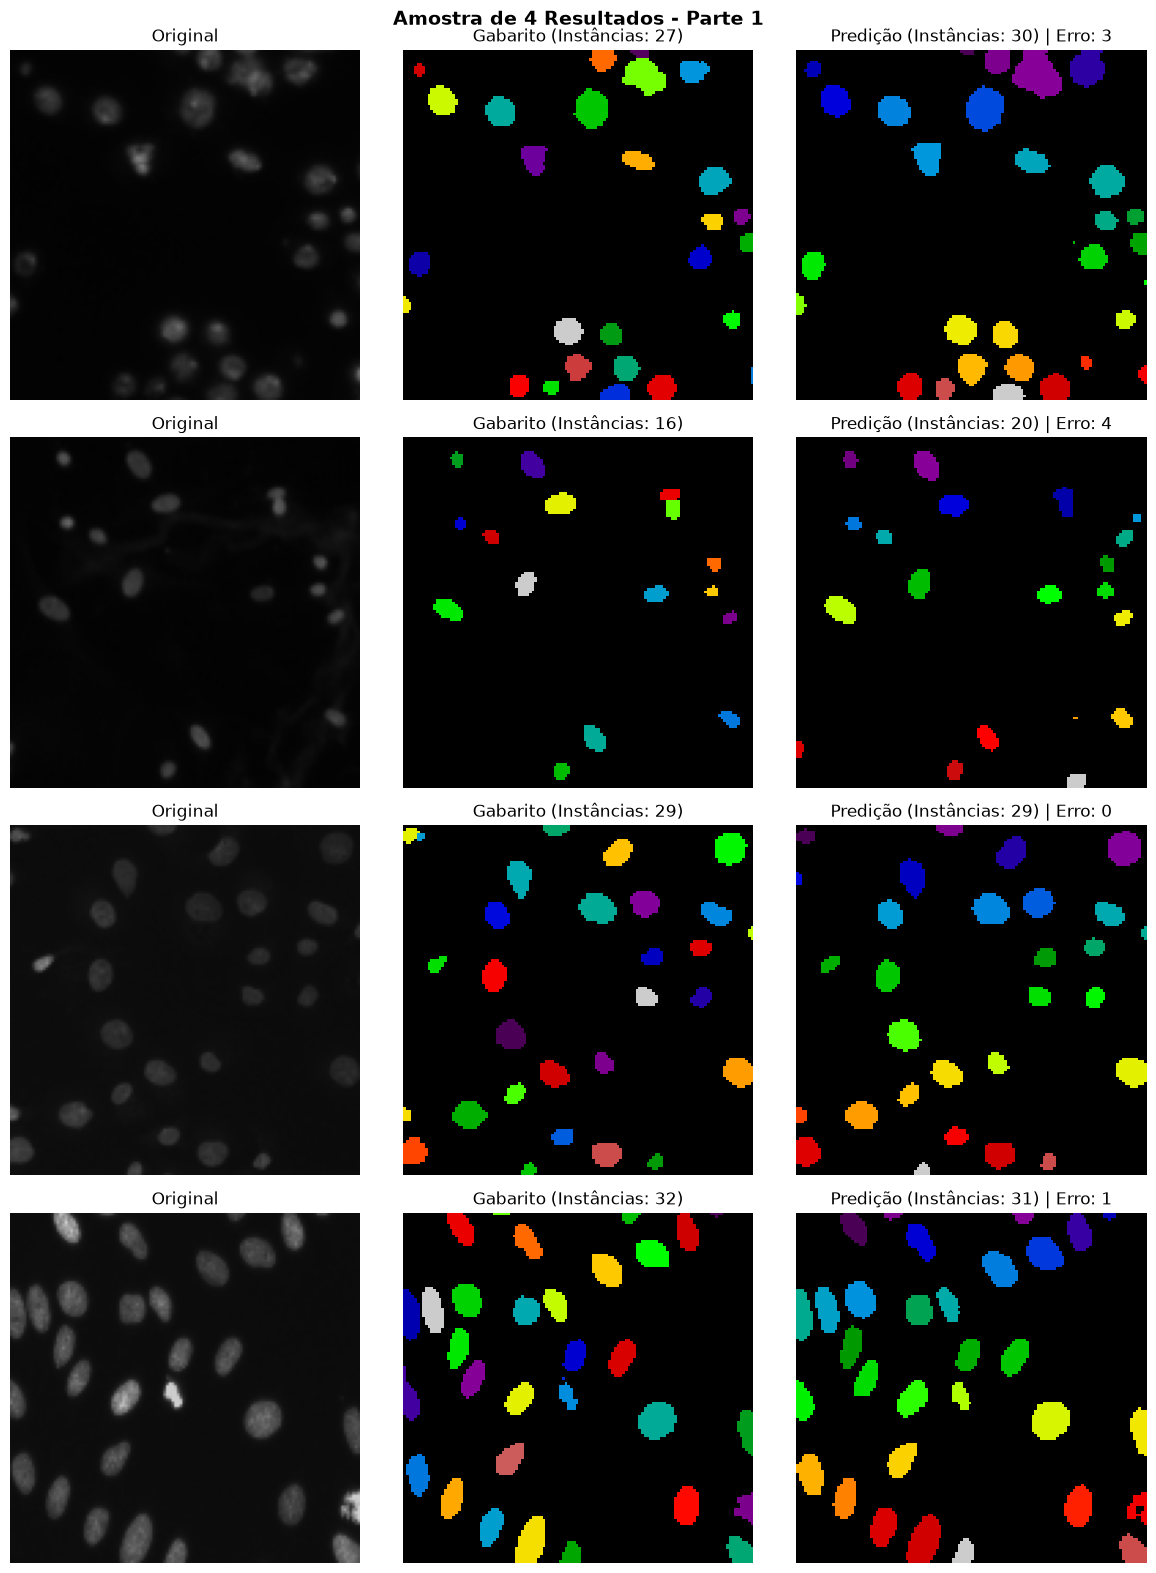

In [22]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=1)

Parte 2 - Trilha B

In [25]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetDDimensional(D=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=2, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Treinando no dispositivo: cpu


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.ndarray was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.ndarray])` or the `torch.serialization.safe_globals([numpy.ndarray])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with weight

Média global mAP: 0.0348
Média global Erro Absoluto de Contagem: 39.5149


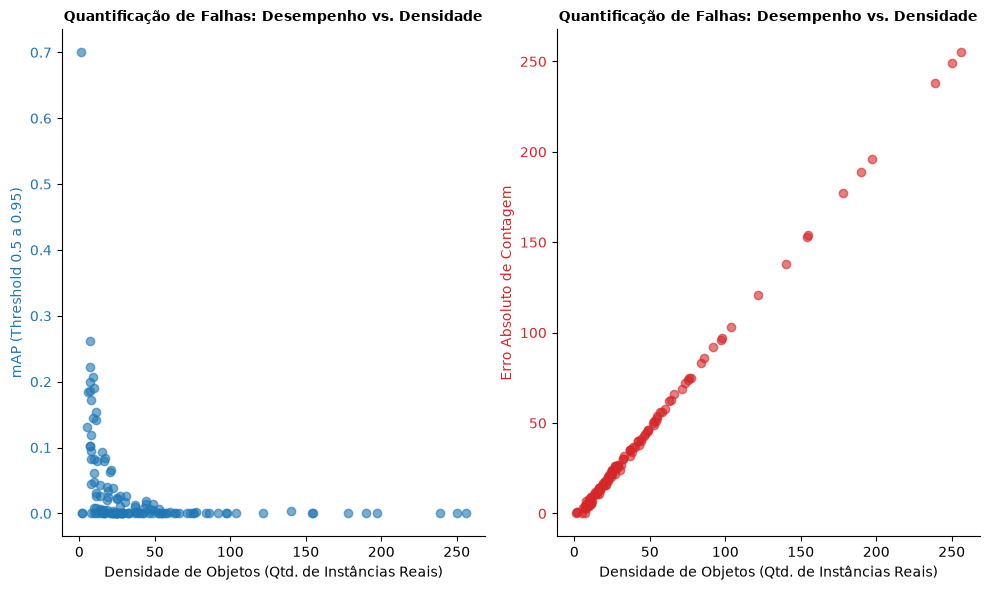

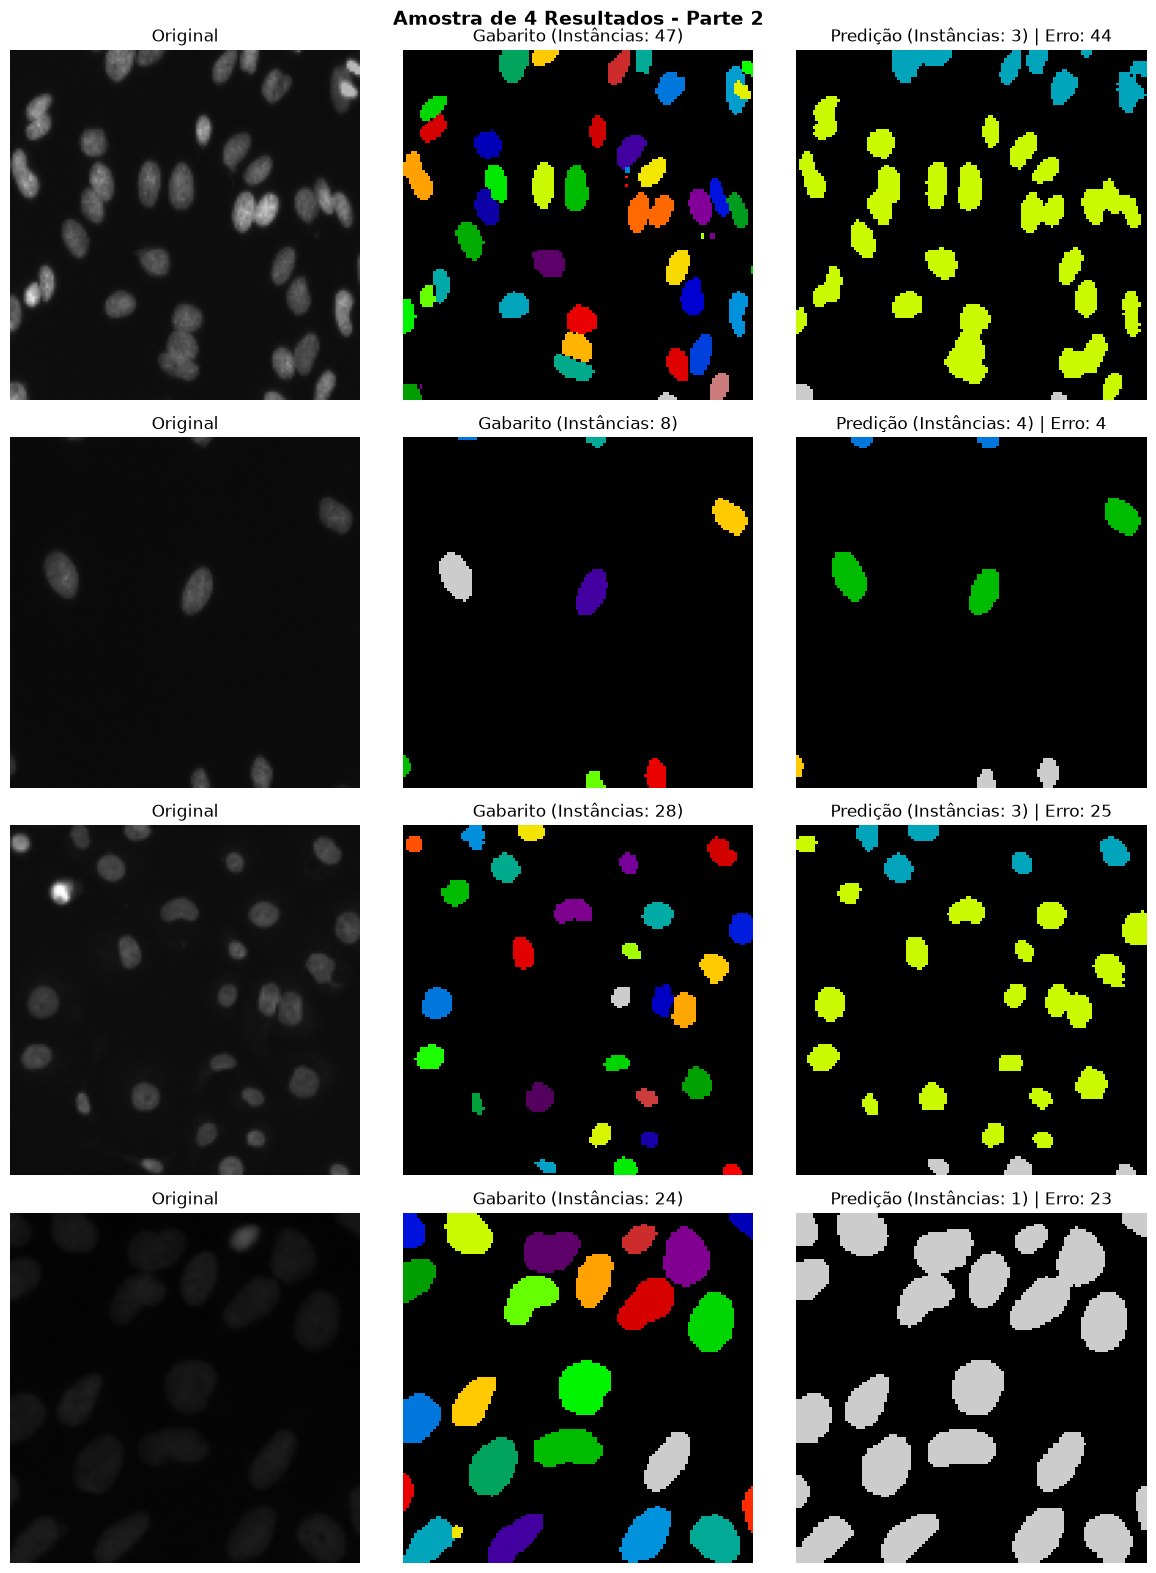

In [ ]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =2)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=2)

## Part 3

Eixos escolhidos 1 e 3

In [ ]:
mean_map_1, std_map_1 = ablation(real_train_loader, real_val_loader, device, axis=1)
mean_map_3, std_map_3 = ablation(real_train_loader, real_val_loader, device, axis=3)

Avaliando Arquitetura: SegNet com seed 42
Epoch 1/10 | Loss: 9.0828 | IoU: 0.0672 | Dice: 0.1260
Epoch 2/10 | Loss: 5.6772 | IoU: 0.0150 | Dice: 0.0296
Epoch 3/10 | Loss: 5.1987 | IoU: 0.0987 | Dice: 0.1797
Epoch 4/10 | Loss: 5.0031 | IoU: 0.2202 | Dice: 0.3609
Epoch 5/10 | Loss: 4.8903 | IoU: 0.2936 | Dice: 0.4539
Epoch 6/10 | Loss: 4.7122 | IoU: 0.3971 | Dice: 0.5685
Epoch 7/10 | Loss: 4.6395 | IoU: 0.4665 | Dice: 0.6362
Epoch 8/10 | Loss: 4.5748 | IoU: 0.5472 | Dice: 0.7073
Epoch 9/10 | Loss: 4.4356 | IoU: 0.6040 | Dice: 0.7531


KeyboardInterrupt: 